In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)

In [2]:
#Load the Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

 - customerID — A unique identifier for each customer. Used to distinguish records; not useful for analysis.
 - gender — Whether the customer is Male or Female.
 - SeniorCitizen — Whether the customer is a senior citizen (65+). Encoded as 1 (yes) or 0 (no).
 - Partner — Whether the customer has a partner or spouse (Yes/No).
 - Dependents — Whether the customer has dependents like children or elderly parents (Yes/No).
 - tenure — How many months the customer has been with the company. Higher tenure usually means a more loyal custome.
 - PhoneService — Whether the customer has a phone/landline service (Yes/No).
 - MultipleLines — Whether the customer has more than one phone line. "No phone service" means they don't have PhoneService at all.
 - InternetService — The type of internet connection: DSL (slower), Fiber optic (faster/premium), or No internet.
 - OnlineSecurity — Whether the customer has an online security add-on (e.g. antivirus, threat protection).
 - OnlineBackup — Whether the customer subscribed to an online data backup service.
 - DeviceProtection — Whether the customer has a device protection/insurance plan.
 - TechSupport — Whether the customer has access to a dedicated tech support service.
 - StreamingTV — Whether the customer streams TV content through their internet plan.
 - StreamingMovies — Whether the customer streams movies through their internet plan.
 - Contract — The type of contract the customer is on. Month-to-month customers are free to leave anytime, so they churn more. One year and     Two year contracts lock customers in longer.
 - PaperlessBilling — Whether the customer receives bills electronically instead of by mail (Yes/No).
 - PaymentMethod — How the customer pays their bill: Electronic check, Mailed check, Bank transfer (automatic), or Credit card (automatic).
 - MonthlyCharges — The amount the customer is billed each month in USD. Higher charges may increase churn risk.
 - TotalCharges — The total amount billed to the customer over their entire tenure. Closely related to tenure × MonthlyCharges. Stored as a
   string — needs to be converted to numeric before use.
 - Churn — The target variable. "Yes" means the customer left the company, "No" means they stayed. This is what you are trying to predict or    analyze.

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
# identify the catgorical column
cat_cols = [col for col in df.columns if df[col].dtype == "object"]
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [5]:
num_col = [col for col in df.columns if df[col].dtype != "object"]
num_col

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# removing customerID not needed
df = df.drop(columns='customerID',axis=1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [8]:
#Change the data type of the TotalCharges to Numeric
df['TotalCharges'] =  pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# Find null values
df[df["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
df = df.drop(df[df['tenure'] == 0].index,axis = 0)

In [12]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## EDA

### Churn distribution

In [13]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

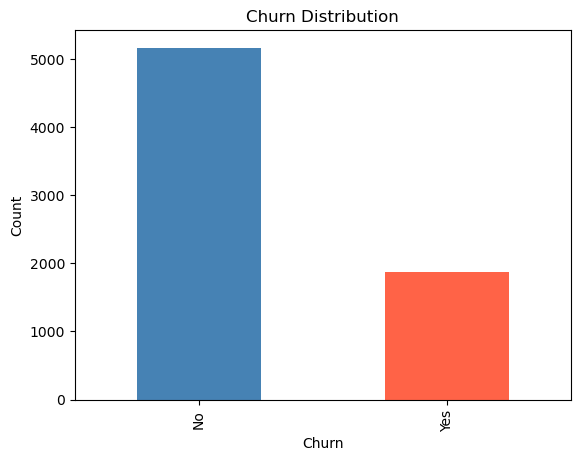

In [14]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- dataset is imbalanced so we need perform sampling  technique to balance the dataset

### Numeric distributions

In [15]:
df.groupby("Churn")["gender"].value_counts()

Churn  gender
No     Male      2619
       Female    2544
Yes    Female     939
       Male       930
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

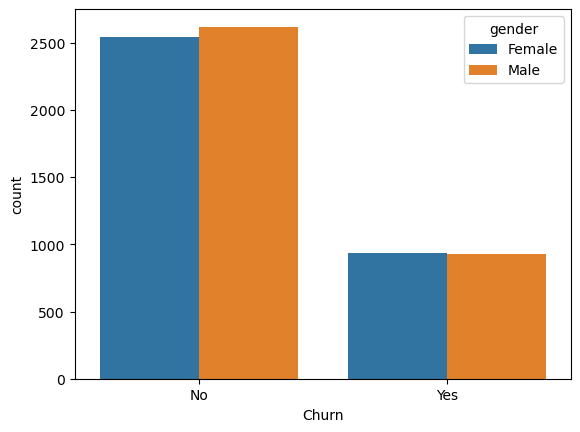

In [16]:
sns.countplot(x='Churn',hue='gender' ,data=df)

In [17]:
df.groupby("Churn")["SeniorCitizen"].value_counts()

Churn  SeniorCitizen
No     0                4497
       1                 666
Yes    0                1393
       1                 476
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

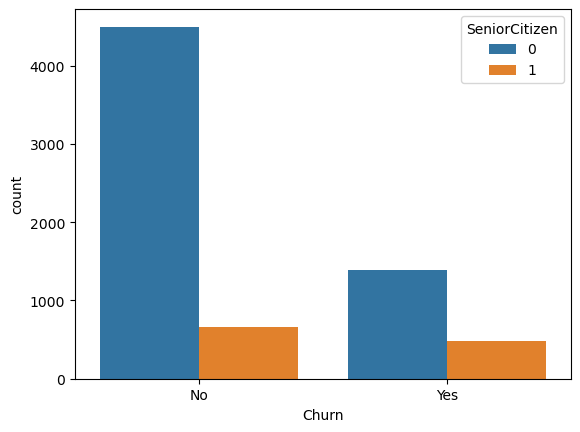

In [18]:
sns.countplot(x="Churn",hue="SeniorCitizen",data=df)

- SeniorCitizen are more likely to churn
- Non-senior churn rate → roughly 24%
- Senior citizen churn rate → roughly 42%

In [19]:
df.groupby("Churn")["Partner"].value_counts(normalize=100)*100

Churn  Partner
No     Yes        52.760023
       No         47.239977
Yes    No         64.205457
       Yes        35.794543
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

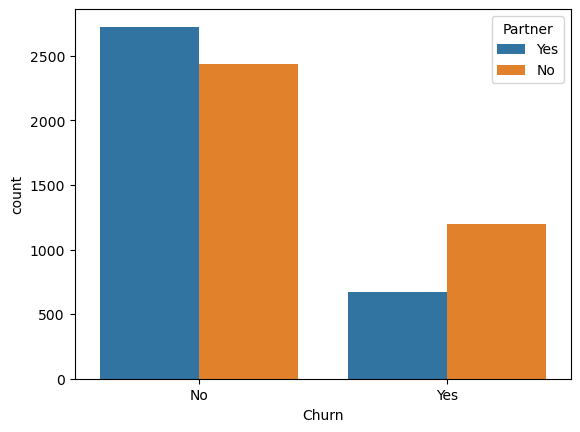

In [20]:
sns.countplot(x ='Churn',hue='Partner',data=df)

- Customers without a partner churn more (64.2%)
- Customers with a partner tend to stay (52.7%)

In [21]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Axes: xlabel='Churn', ylabel='count'>

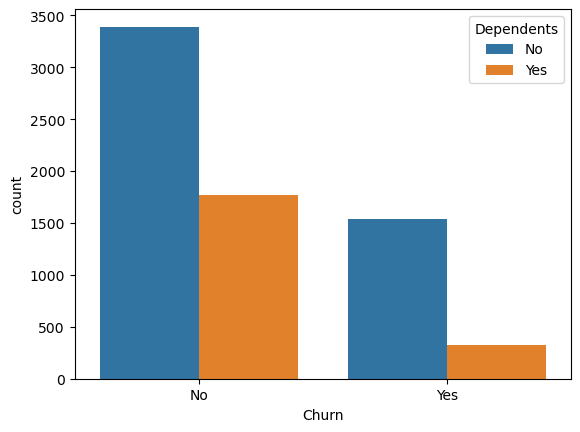

In [22]:
sns.countplot(x ='Churn',hue='Dependents',data=df)

- Customers without dependents churn almost twice as much (31.3%)
- Customers with dependents are much more loyal (15.9%)
- 
### Why? 🤔
- Customers with dependents use family plans which are harder to cancel
- They need stable, reliable service for their family
- Single/no dependent customers can switch easily
- Family customers get more value from the service


<Axes: xlabel='Churn', ylabel='count'>

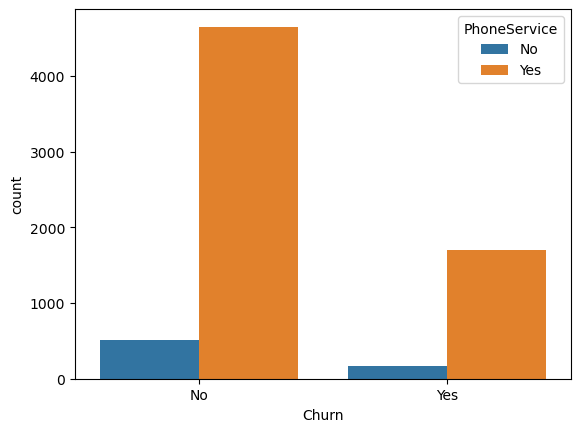

In [23]:
sns.countplot(x ='Churn',hue='PhoneService',data=df)

### Key Insight 🔍

- Churn rate is almost the same for both groups
- With Phone Service → 27%
- Without Phone Service → 28.6%
- Difference is only 1.6% which is very small


### What this means? 🤔

- PhoneService is NOT a strong predictor of churn
- Whether a customer has phone service or not does not significantly affect their decision to leave
- Other features like Contract, tenure, MonthlyCharges are much more important



<Axes: xlabel='Churn', ylabel='count'>

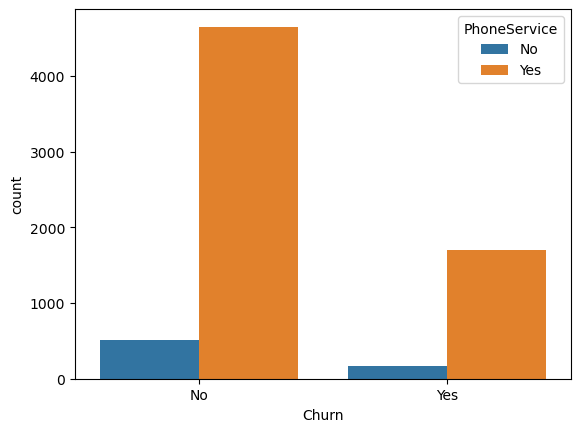

In [24]:
sns.countplot(x ='Churn',hue='PhoneService',data=df)

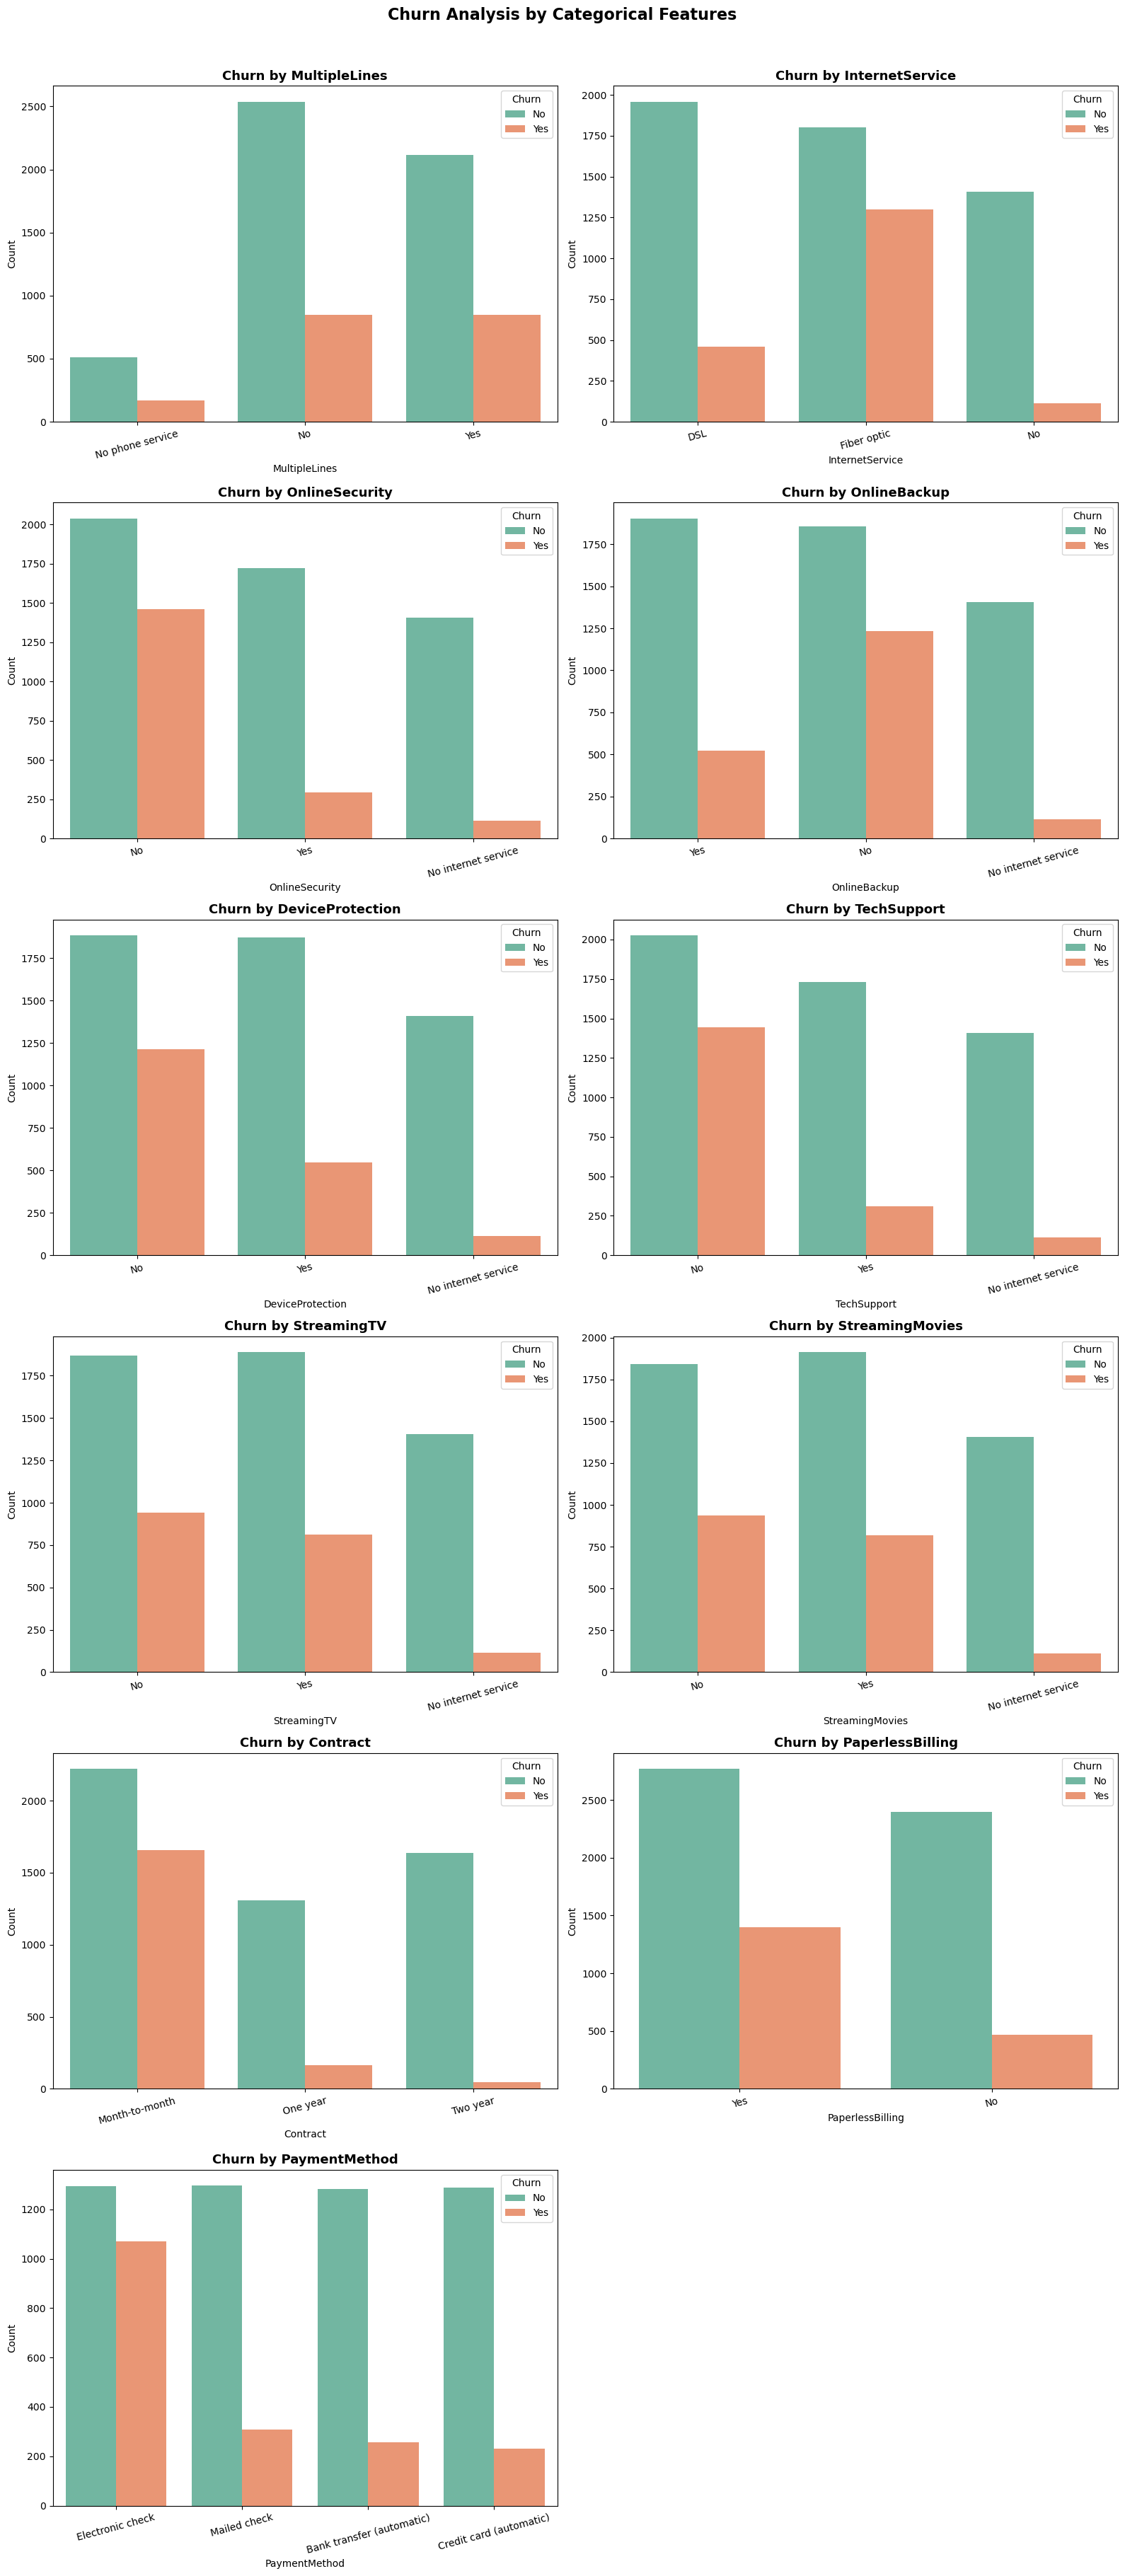

           INSIGHTS FOR EACH FEATURE

📊 MultipleLines
----------------------------------------
                  Not Churned %  Churned %
MultipleLines                             
No                         74.9       25.1
No phone service           75.0       25.0
Yes                        71.4       28.6

  ⚠️  Highest churn : Yes → 28.6%
  ✅  Lowest churn  : No phone service → 25.0%

📊 InternetService
----------------------------------------
                 Not Churned %  Churned %
InternetService                          
DSL                       81.0       19.0
Fiber optic               58.1       41.9
No                        92.6        7.4

  ⚠️  Highest churn : Fiber optic → 41.9%
  ✅  Lowest churn  : No → 7.4%

📊 OnlineSecurity
----------------------------------------
                     Not Churned %  Churned %
OnlineSecurity                               
No                            58.2       41.8
No internet service           92.6        7.4
Yes                   

In [25]:
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(6, 2, figsize=(16, 36))  # changed 5,2 to 6,2
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'Churn by {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Churn Analysis by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ---- Insights ----
print("=" * 60)
print("           INSIGHTS FOR EACH FEATURE")
print("=" * 60)

for col in cat_cols:
    print(f"\n📊 {col}")
    print("-" * 40)
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).unstack() * 100
    churn_rate.columns = ['Not Churned %', 'Churned %']
    churn_rate = churn_rate.round(1)
    print(churn_rate)
    
    highest = churn_rate['Churned %'].idxmax()
    highest_val = churn_rate['Churned %'].max()
    lowest = churn_rate['Churned %'].idxmin()
    lowest_val = churn_rate['Churned %'].min()
    
    print(f"\n  ⚠️  Highest churn : {highest} → {highest_val}%")
    print(f"  ✅  Lowest churn  : {lowest} → {lowest_val}%")

## Tenure vs Churn boxplot

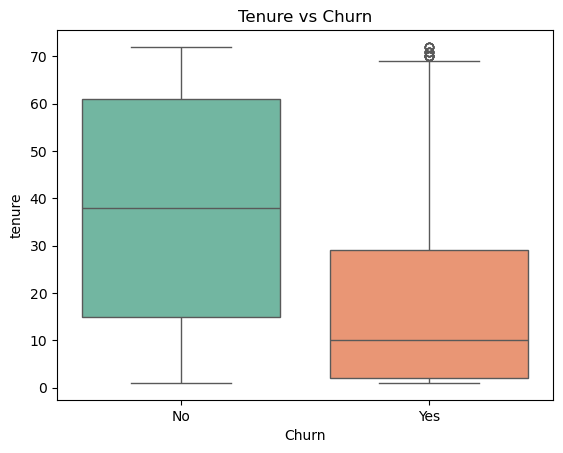

In [26]:
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')
plt.title('Tenure vs Churn')
plt.show()

### Monthly Charges vs Churn

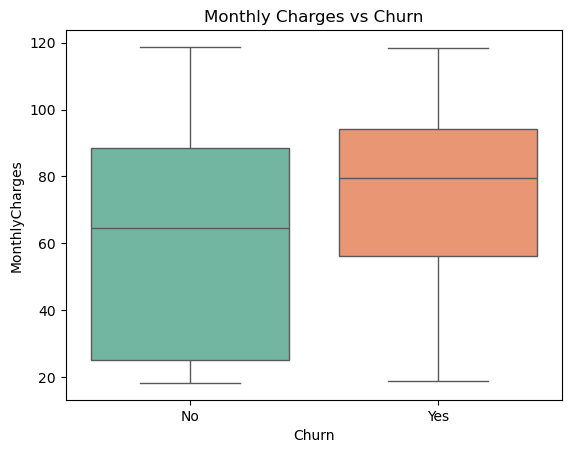

In [27]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

### Key Insight 🔍

- Customers who churn leave very early in their journey
- Longer the tenure → less likely to churn
- Most churned customers leave within the first 10 months
- After 30+ months customers become very loyal


### Why? 🤔

- New customers are still exploring options
- They haven't built loyalty or attachment yet
- Early bad experiences push them to switch immediately
- Long term customers are comfortable and satisfied

### Correlation heatmap

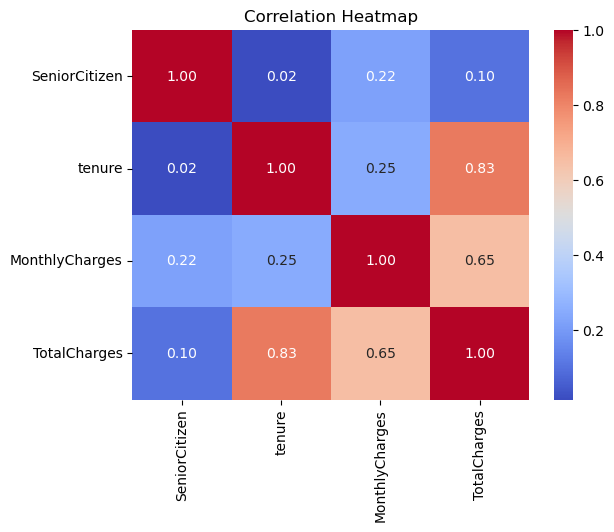

In [28]:
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Key Insights 🔍
- 🔴 Strong Correlation (0.83) — tenure vs TotalCharges

- Very obvious — longer the tenure → higher the total bill
- These two are highly related — may cause multicollinearity in model
- Consider dropping TotalCharges before modeling

- 🟠 Moderate Correlation (0.65) — MonthlyCharges vs TotalCharges

Higher monthly charges → higher total charges
Again TotalCharges is redundant since it depends on both tenure and MonthlyCharges

- 🔵 Weak Correlation (0.25) — tenure vs MonthlyCharges

- Slight relationship — longer customers may have upgraded plans
- Not a concern

- 🔵 Weak Correlation (0.22) — SeniorCitizen vs MonthlyCharges

- Senior citizens pay slightly higher monthly charges
- Could be due to premium plans or lack of discounts

- ⚪ Very Weak (0.02) — SeniorCitizen vs tenure

- Almost no relationship at all

## Label Encoder

In [29]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [30]:
cat_cols = [col for col in df.columns if df[col].dtype =="object"]
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [31]:
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0


### Segrgating the X and Y

In [34]:
X = df.drop('Churn',axis =1) # Features (independent variables)
y = df["Churn"] # Target (dependent variable)

In [35]:
X.head(2)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50


In [36]:
y.head(2)

0    0
1    0
Name: Churn, dtype: int64

## Train Test Split

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) # aslo use startify=y for distribution will change 

## Over sampling

In [39]:
from imblearn.over_sampling import SMOTE

In [40]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [41]:
X_train_sm.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,0,43,0,1,0,0,0,2,0,2,2,0,1,0,49.05,2076.20
1,1,0,0,0,3,1,0,0,0,0,0,0,2,0,0,0,1,53.40,188.70
2,0,0,1,0,55,1,2,1,0,0,2,0,0,0,0,1,2,77.75,4458.15
3,1,0,1,1,45,1,0,0,2,0,0,2,0,0,2,0,0,54.65,2553.70
4,0,0,1,1,55,1,2,1,2,0,0,0,2,2,1,0,3,100.90,5448.60


In [42]:
y_train_sm.head()

0    1
1    1
2    1
3    0
4    0
Name: Churn, dtype: int64

## Model Building

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [51]:
# Train model
model = LogisticRegression()
model.fit(X_train_sm, y_train_sm)

# Predict using TEST data (not training target)
y_pred = model.predict(X_test)

# Evaluate

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81      1033
           1       0.51      0.70      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407



## Random Forest

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [52]:
model = RandomForestClassifier()
model.fit(X_train_sm,y_train_sm)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.56      0.57      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407



## Cat Boost

CatBoost is a powerful gradient boosting algorithm developed by Yandex, especially known for handling categorical data automatically
- ✅ Handles categorical features directly (no need for one-hot encoding)
- ✅ Works well with imbalanced datasets
- ✅ Less overfitting compared to other boosting models
- ✅ Very good performance out-of-the-box

In [53]:
pip install catboost


   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.0 MB/s eta 0:00:49
   ---------------------------------------- 1.0/100.2 MB 1.8 MB/s eta 0:00:54
    --------------------------------------- 1.8/100.2 MB 2.3 MB/s eta 0:00:43
   - -------------------------------------- 2.6/100.2 MB 2.7 MB/s eta 0:00:37
   - -------------------------------------- 3.4/100.2 MB 2.7 MB/s eta 0:00:36
   - -------------------------------------- 3.9/100.2 MB 2.7 MB/s eta 0:00:36
   - -------------------------------------- 4.7/100.2 MB 2.8 MB/s eta 0:00:34
   -- ------------------------------------- 6.0/100.2 MB 3.2 MB/s eta 0:00:30
   --- ------------------------------------ 7.6/100.2 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.7/100.2 MB 3.8 MB/s eta 0:00:25
   --- ------------------------------------ 10.0/100.2 MB 4.0 MB/s eta 0:00:2

In [54]:
from catboost import CatBoostClassifier

In [55]:
model = CatBoostClassifier()
model.fit(X_train_sm,y_train_sm)

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))

Learning rate set to 0.02538
0:	learn: 0.6770939	total: 157ms	remaining: 2m 36s
1:	learn: 0.6617937	total: 165ms	remaining: 1m 22s
2:	learn: 0.6474384	total: 172ms	remaining: 57.3s
3:	learn: 0.6354602	total: 179ms	remaining: 44.6s
4:	learn: 0.6240480	total: 187ms	remaining: 37.3s
5:	learn: 0.6140977	total: 196ms	remaining: 32.4s
6:	learn: 0.6041692	total: 203ms	remaining: 28.9s
7:	learn: 0.5942828	total: 212ms	remaining: 26.3s
8:	learn: 0.5855583	total: 221ms	remaining: 24.4s
9:	learn: 0.5756339	total: 229ms	remaining: 22.7s
10:	learn: 0.5652545	total: 238ms	remaining: 21.4s
11:	learn: 0.5560575	total: 246ms	remaining: 20.2s
12:	learn: 0.5485654	total: 254ms	remaining: 19.3s
13:	learn: 0.5415973	total: 262ms	remaining: 18.4s
14:	learn: 0.5339947	total: 269ms	remaining: 17.7s
15:	learn: 0.5271455	total: 277ms	remaining: 17s
16:	learn: 0.5209328	total: 285ms	remaining: 16.5s
17:	learn: 0.5141939	total: 293ms	remaining: 16s
18:	learn: 0.5085515	total: 300ms	remaining: 15.5s
19:	learn: 0.5